In [1]:
import pandas as pd

df = pd.read_csv("../data/train.csv")

df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [2]:
df.shape

(48120, 4)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 2.3 MB


In [4]:
df.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [5]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  48120 non-null  datetime64[us]
 1   Junction  48120 non-null  int64         
 2   Vehicles  48120 non-null  int64         
 3   ID        48120 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 1.5 MB


In [6]:
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek

df.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6


In [7]:
df.groupby('Junction')['Vehicles'].mean()

Junction
1    45.052906
2    14.253221
3    13.694010
4     7.251611
Name: Vehicles, dtype: float64

In [8]:
df.groupby('Hour')['Vehicles'].mean()

Hour
0     23.540648
1     19.654863
2     17.102743
3     14.847382
4     12.973067
5     12.173566
6     12.980050
7     14.703242
8     16.402993
9     19.379551
10    24.229925
11    27.495262
12    28.403990
13    25.588529
14    27.702743
15    27.650374
16    26.674314
17    26.648379
18    28.095262
19    29.854863
20    29.824938
21    28.202993
22    27.226933
23    25.635411
Name: Vehicles, dtype: float64

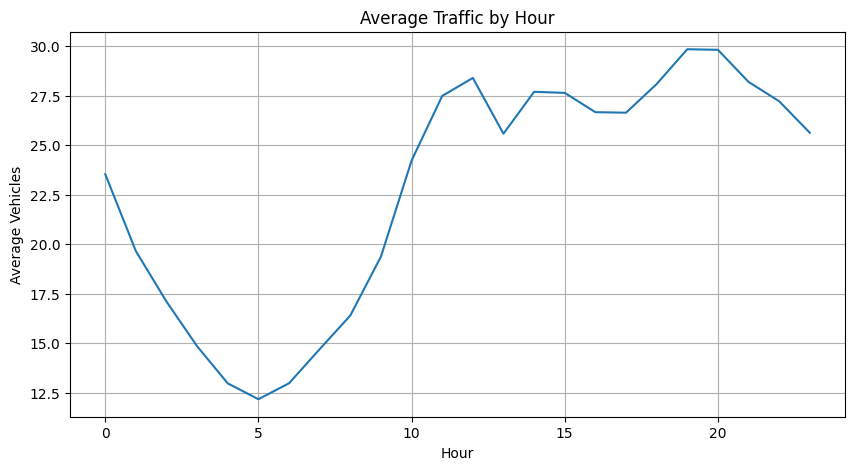

In [9]:
import matplotlib.pyplot as plt

hourly_traffic = df.groupby('Hour')['Vehicles'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_traffic.index,
         hourly_traffic.values)

plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Vehicles")
plt.grid()

plt.show()

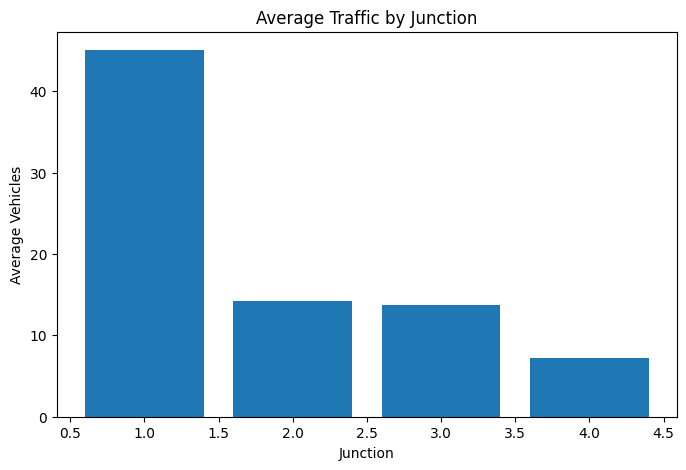

In [10]:
import matplotlib.pyplot as plt

junction_traffic = df.groupby('Junction')['Vehicles'].mean()

plt.figure(figsize=(8,5))
plt.bar(junction_traffic.index,
        junction_traffic.values)

plt.title("Average Traffic by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Vehicles")

plt.show()

In [11]:
df['DayOfWeek'] = df['DateTime'].dt.dayofweek

df.groupby('DayOfWeek')['Vehicles'].mean()

DayOfWeek
0    24.409408
1    25.286731
2    25.149681
3    25.152875
4    23.802120
5    18.544611
6    17.134727
Name: Vehicles, dtype: float64

In [12]:
features = ['Junction',
            'Year',
            'Month',
            'Day',
            'Hour',
            'DayOfWeek']

X = df[features]

y = df['Vehicles']

print(X.shape)
print(y.shape)

(48120, 6)
(48120,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(38496, 6)
(9624, 6)


In [14]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [15]:
predictions = model.predict(X_test)

predictions[:10]

array([ 9.8 , 48.76,  8.16, 11.29, 19.14,  9.74, 12.1 , 14.8 , 14.23,
       27.95])

In [16]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 2.3966500415627596
R2 Score: 0.9689627529667615


In [17]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,Junction,0.516292
1,Year,0.167194
4,Hour,0.144076
5,DayOfWeek,0.072565
2,Month,0.067681
3,Day,0.032193


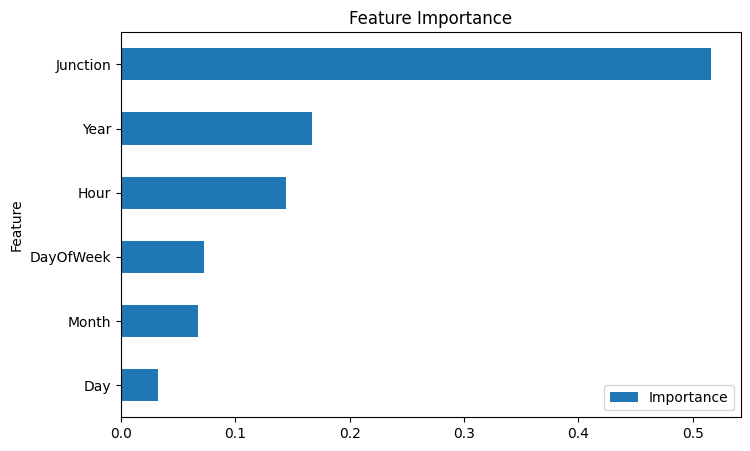

In [18]:
import matplotlib.pyplot as plt

importance.sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

In [19]:
df['Traffic_Level'] = pd.cut(
    df['Vehicles'],
    bins=[0,10,20,40,1000],
    labels=[
        'Low',
        'Medium',
        'High',
        'Peak'
    ]
)

df['Traffic_Level'].value_counts()

Traffic_Level
Low       15687
Medium    14897
High       9899
Peak       7637
Name: count, dtype: int64

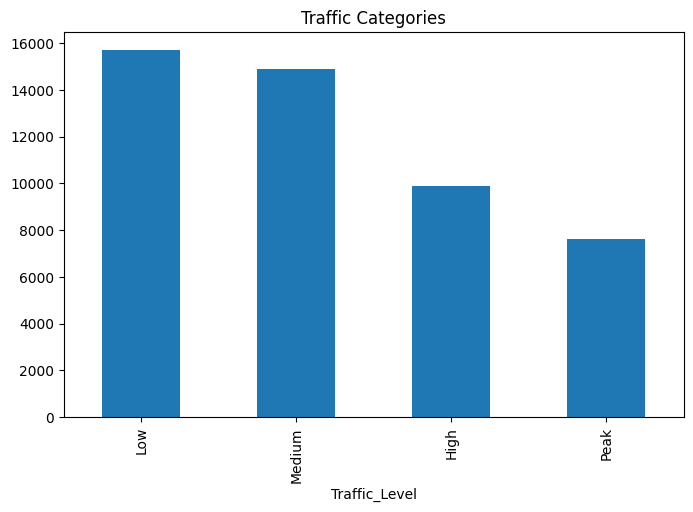

In [20]:
df['Traffic_Level'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Traffic Categories")
plt.show()

In [21]:
df['IsWeekend'] = (
    df['DayOfWeek'] >= 5
).astype(int)

df[['DayOfWeek','IsWeekend']].head()

,DayOfWeek,IsWeekend
0,6,1
1,6,1
2,6,1
3,6,1
4,6,1


In [22]:
df['WeekOfYear'] = (
    df['DateTime']
    .dt
    .isocalendar()
    .week
)

In [23]:
df['Quarter'] = (
    df['DateTime']
    .dt
    .quarter
)

In [24]:
def get_season(month):

    if month in [12,1,2]:
        return 0   # Winter

    elif month in [3,4,5]:
        return 1   # Summer

    elif month in [6,7,8,9]:
        return 2   # Monsoon

    else:
        return 3   # Post-Monsoon

df['Season'] = df['Month'].apply(
    get_season
)

In [25]:
def rush_hour(hour):

    if 8 <= hour <= 10:
        return 1

    elif 17 <= hour <= 20:
        return 1

    else:
        return 0

In [26]:
df['RushHour'] = df['Hour'].apply(
    rush_hour
)

In [27]:
holiday_dates = [

    '2015-01-26',
    '2015-08-15',
    '2015-10-02',

    '2016-01-26',
    '2016-08-15',
    '2016-10-02',

    '2017-01-26',
    '2017-08-15'
]
holiday_dates = pd.to_datetime(
    holiday_dates
)
df['IsHoliday'] = (
    df['DateTime']
    .dt
    .normalize()
    .isin(holiday_dates)
).astype(int)
df['IsHoliday'].value_counts()


IsHoliday
0    47808
1      312
Name: count, dtype: int64

In [28]:
df.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek,Traffic_Level,IsWeekend,WeekOfYear,Quarter,Season,RushHour,IsHoliday
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6,Medium,1,44,4,3,0,0
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6,Medium,1,44,4,3,0,0
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6,Low,1,44,4,3,0,0
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6,Low,1,44,4,3,0,0
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6,Low,1,44,4,3,0,0


In [29]:
features = [
    'Junction',
    'Year',
    'Month',
    'Day',
    'Hour',
    'DayOfWeek',
    'IsWeekend',
    'IsHoliday',
    'WeekOfYear',
    'Quarter',
    'Season',
    'RushHour'
]

X = df[features]
y = df['Vehicles']

print(X.shape)

(48120, 12)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestRegressor

model_v2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_train, y_train)

print("Mega Model Trained!")

Mega Model Trained!


In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

pred_v2 = model_v2.predict(X_test)

mae_v2 = mean_absolute_error(
    y_test,
    pred_v2
)

r2_v2 = r2_score(
    y_test,
    pred_v2
)

print("MAE:", mae_v2)
print("R2:", r2_v2)

MAE: 2.3773243973399834
R2: 0.9690014084013662


In [33]:
comparison = pd.DataFrame({
    'Model': ['Baseline RF','Mega RF'],
    'MAE': [2.39665, mae_v2],
    'R2': [0.96896, r2_v2]
})

comparison

,Model,MAE,R2
0,Baseline RF,2.396650,0.968960
1,Mega RF,2.377324,0.969001


In [34]:
import pickle

with open('../models/traffic_model.pkl', 'wb') as file:
    pickle.dump(model_v2, file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [35]:
import pickle

with open('../models/traffic_model.pkl', 'wb') as file:
    pickle.dump(model_v2, file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [36]:
import pickle

with open('../models/traffic_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
